# Audio Deepfake Detection: MFAAN + CAF-Net on MLADDC


In [9]:
# ==============================================================================
# CELL 1: IMPORTS, CONFIG, PATHS
# ==============================================================================
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm.auto import tqdm
from scipy.fftpack import dct
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              roc_curve)

# ── Paths ─────────────────────────────────────────────────────────────────────
T3_BASE        = Path("/kaggle/input/datasets/artharking/mladdc-t3/T3")
WORK_DIR       = Path("/kaggle/working")
T3_SLIDING_DIR = WORK_DIR / "t3_sliding_cache"
MODELS         = WORK_DIR / "models"
RESULTS        = WORK_DIR / "results"
for d in [T3_SLIDING_DIR, MODELS, RESULTS]:
    d.mkdir(parents=True, exist_ok=True)

# ── Feature config ────────────────────────────────────────────────────────────
SR         = 16000
DURATION   = 4.0
HOP        = 256
N_FFT      = 512
N_MFCC     = 40
N_LFCC     = 40
N_CHROMA   = 12
N_FRAMES   = int(SR * DURATION / HOP) + 1   # 251

# ── Sliding window config ─────────────────────────────────────────────────────
WIN_DURATION = 4.0
HOP_DURATION = 1.0

# ── Model config ──────────────────────────────────────────────────────────────
CAF_CLASSES      = 3
CLASS_NAMES_CAF  = ["real", "fake", "half-truth"]
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED             = 42

def set_seed(s=42):
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f"Device : {DEVICE}")
print(f"N_FRAMES: {N_FRAMES}")

Device : cpu
N_FRAMES: 251


In [2]:
# ==============================================================================
# CELL 2: CAFNET ARCHITECTURE
# (must match exactly what was used during training)
# ==============================================================================

class DSConv1d(nn.Module):
    def __init__(self, ic, oc, k, p):
        super().__init__()
        self.dw = nn.Conv1d(ic, ic, k, padding=p, groups=ic)
        self.pw = nn.Conv1d(ic, oc, 1)
    def forward(self, x): return self.pw(self.dw(x))


class SelfAttn1d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        hid = max(ch // 8, 1)
        self.q = nn.Conv1d(ch, hid, 1)
        self.k = nn.Conv1d(ch, hid, 1)
        self.v = nn.Conv1d(ch, ch,  1)
        self.g = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        q = self.q(x).permute(0,2,1)
        a = F.softmax(torch.bmm(q, self.k(x)), dim=-1)
        return self.g * torch.bmm(self.v(x), a.permute(0,2,1)) + x


class EnhancedPath(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            DSConv1d(in_ch, 64, 3, 1), nn.BatchNorm1d(64),
            nn.ReLU(), nn.Dropout(0.3),
            DSConv1d(64, 128, 3, 1),   nn.BatchNorm1d(128),
            nn.ReLU(), nn.Dropout(0.3),
        )
        self.attn = SelfAttn1d(128)
        self.pool = nn.MaxPool1d(2)
    def forward(self, x):
        return self.pool(self.attn(self.net(x.squeeze(1))))


class CrossAttnFusion(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.ca   = nn.MultiheadAttention(dim, num_heads=8, batch_first=True)
        self.gate = nn.Linear(dim*3, 3)
        self.proj = nn.Linear(dim, dim)
    def forward(self, m, l, c):
        ms = m.permute(0,2,1); ls = l.permute(0,2,1); cs = c.permute(0,2,1)
        kv = torch.cat([ls, cs], dim=1)
        attn_out, _ = self.ca(ms, kv, kv)
        mp = ms.mean(1); lp = ls.mean(1); cp = cs.mean(1)
        gates = F.softmax(self.gate(torch.cat([mp,lp,cp], dim=1)), dim=1)
        fused = gates[:,0:1]*mp + gates[:,1:2]*lp + gates[:,2:3]*cp
        return self.proj(fused)   # (B, 128)


class TemporalHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(384, 64, num_layers=2, bidirectional=True,
                            batch_first=True, dropout=0.3)
        self.fc   = nn.Linear(128, 2)
    def forward(self, x):
        out, _ = self.lstm(x.permute(0,2,1))
        return torch.sigmoid(self.fc(out[:,-1,:]))


class CAFNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.mfcc_p   = EnhancedPath(N_MFCC)
        self.lfcc_p   = EnhancedPath(N_LFCC)
        self.chroma_p = EnhancedPath(N_CHROMA)
        self.fusion   = CrossAttnFusion(128)
        self.head = nn.Sequential(
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, CAF_CLASSES),
        )
        self.aux      = nn.Linear(128, CAF_CLASSES)
        self.temporal = TemporalHead()

    def forward(self, mfcc, lfcc, chroma):
        mf = self.mfcc_p(mfcc)
        lf = self.lfcc_p(lfcc)
        cf = self.chroma_p(chroma)
        pre_pool = torch.cat([mf, lf, cf], dim=1)   # (B, 384, T/2)
        fused    = self.fusion(mf, lf, cf)           # (B, 128)
        cls_main = self.head(fused)
        cls_aux  = self.aux(fused)
        temporal = self.temporal(pre_pool)
        return cls_main, cls_aux, temporal


# ── Load checkpoint ───────────────────────────────────────────────────────────
cafnet = CAFNet().to(DEVICE)
ckpt_path = "/kaggle/input/models/piwoobeep/cafnet/pytorch/default/1/cafnet_unified.pth"
cafnet.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
cafnet.eval()
print(f"Loaded checkpoint: {ckpt_path}")
print(f"Parameters: {sum(p.numel() for p in cafnet.parameters()):,}")

Loaded checkpoint: /kaggle/input/models/piwoobeep/cafnet/pytorch/default/1/cafnet_unified.pth
Parameters: 576,414


In [10]:
# ==============================================================================
# CELL 3: FEATURE HELPERS
# Compute MFCC, LFCC, Chroma from a raw waveform segment.
# Used inside the sliding-window inference loop.
# ==============================================================================

def _compute_lfcc(y, sr=SR, n_lfcc=N_LFCC, n_fft=N_FFT,
                  hop=HOP, n_filters=128):
    S     = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop)) ** 2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    centers = np.linspace(0, freqs[-1], n_filters + 2)
    fb = np.zeros((n_filters, len(freqs)), dtype=np.float32)
    for i in range(n_filters):
        fl, fc, fr = centers[i], centers[i+1], centers[i+2]
        for j, f in enumerate(freqs):
            if fl <= f <= fc:
                fb[i, j] = (f - fl) / (fc - fl + 1e-10)
            elif fc < f <= fr:
                fb[i, j] = (fr - f) / (fr - fc + 1e-10)
    log_e = np.log(np.dot(fb, S) + 1e-10)
    return dct(log_e, type=2, axis=0, norm="ortho")[:n_lfcc]


def extract_window_features(y_segment: np.ndarray,
                             n_frames: int = N_FRAMES) -> tuple:
    """
    Given a raw waveform segment of exactly SR*WIN_DURATION samples,
    return (mfcc, lfcc, chroma) each shaped (n_coeff, N_FRAMES).
    """
    target = int(SR * WIN_DURATION)
    if len(y_segment) < target:
        y_segment = np.pad(y_segment, (0, target - len(y_segment)))
    else:
        y_segment = y_segment[:target]

    def _fix(arr):
        if arr.shape[1] < n_frames:
            arr = np.pad(arr, ((0, 0), (0, n_frames - arr.shape[1])))
        return arr[:, :n_frames].astype(np.float32)

    mfcc   = _fix(librosa.feature.mfcc(y=y_segment, sr=SR, n_mfcc=N_MFCC,
                                        n_fft=N_FFT, hop_length=HOP))
    lfcc   = _fix(_compute_lfcc(y_segment))
    chroma = _fix(librosa.feature.chroma_stft(y=y_segment, sr=SR,
                                               n_fft=N_FFT, hop_length=HOP))
    return mfcc, lfcc, chroma


def features_to_tensors(mfcc, lfcc, chroma):
    """
    Add batch and channel dims: (n_coeff, T) -> (1, 1, n_coeff, T).
    """
    to_t = lambda a: torch.from_numpy(a).unsqueeze(0).unsqueeze(0).to(DEVICE)
    return to_t(mfcc), to_t(lfcc), to_t(chroma)


print("Feature helpers defined.")

Feature helpers defined.


In [11]:
# ==============================================================================
# CELL 4: METADATA LOADER
# Reads the XLSX files in each split directory to build a dict of
#   wav_path -> (t_fake_start_s, t_fake_end_s)
# for all matched Half-Truth wav files.
# ==============================================================================
import pandas as pd

def _load_xlsx_meta(xlsx_path: Path) -> dict:
    df = pd.read_excel(xlsx_path, engine="openpyxl")
    df.columns = df.columns.str.lower().str.strip()
    cols = list(df.columns)

    def _pick(exact_set, fallback_substrings):
        for c in cols:
            if c in exact_set: return c
        for c in cols:
            if any(s in c for s in fallback_substrings): return c
        return None

    fn_col = _pick({"mixed file"},               ("mixed",))
    st_col = _pick({"start of replacement (s)"}, ("start",))
    en_col = _pick({"end of replacement (s)"},   ("end",))

    missing = [name for name, col in
               [("filename", fn_col), ("start", st_col), ("end", en_col)]
               if col is None]
    if missing:
        raise RuntimeError(
            f"XLSX '{xlsx_path.name}' -- could not resolve columns: {missing}\n"
            f"  Found: {cols}"
        )

    meta = {}
    for _, row in df.iterrows():
        stem = Path(str(row[fn_col]).strip()).stem
        t_s, t_e = float(row[st_col]), float(row[en_col])
        if t_e <= t_s:
            print(f"  [WARN] '{stem}' t_end={t_e} <= t_start={t_s} -- skipped")
            continue
        meta[stem] = (t_s, t_e)
    return meta


def load_t3_metadata(split_dir: Path) -> dict:
    """
    Returns {wav_path: (t_fake_start_s, t_fake_end_s)} for all
    matched Half-Truth wav files in split_dir.
    """
    half_truth_dir = split_dir / "Half-Truth"
    if not half_truth_dir.exists():
        raise FileNotFoundError(f"Half-Truth folder not found: {half_truth_dir}")

    xlsx_files = list(split_dir.glob("*.xlsx"))
    if not xlsx_files:
        raise FileNotFoundError(f"No xlsx found in {split_dir}")

    combined = {}
    for xf in xlsx_files:
        print(f"  [meta] {xf.name} ...")
        try:
            chunk = _load_xlsx_meta(xf)
            combined.update(chunk)
            print(f"         -> {len(chunk)} entries")
        except Exception as e:
            print(f"  [WARN] {xf.name}: {e}")

    if not combined:
        raise RuntimeError("No metadata loaded.")

    meta, unmatched = {}, []
    for wav in sorted(half_truth_dir.glob("*.wav")):
        if wav.stem in combined:
            meta[wav] = combined[wav.stem]
        else:
            unmatched.append(wav.name)

    if unmatched:
        print(f"  [WARN] {len(unmatched)} unmatched wavs (first 5):")
        for n in unmatched[:5]: print(f"         {n}")

    print(f"  [meta] Matched {len(meta)} / "
          f"{len(list(half_truth_dir.glob('*.wav')))} wav files")
    return meta


test_meta = load_t3_metadata(T3_BASE / "test")
print(f"\nTest set: {len(test_meta)} half-truth files ready for inference.")

  [meta] test_hifi.xlsx ...
         -> 8000 entries
  [meta] test_bigv.xlsx ...
         -> 8000 entries
  [meta] Matched 16000 / 16000 wav files

Test set: 16000 half-truth files ready for inference.


In [20]:
# ==============================================================================
# CELL 5: TEST EVALUATION
#
# Tests CAFNet the way it was trained:
#   - For each half-truth test file, cut exactly one 4-second window
#     such that the splice is fully inside (random placement within valid range)
#   - Feed that window to CAFNet
#   - Read norm_start, norm_end from TemporalHead directly
#   - Convert to absolute seconds and compute error
#
# This is the fair evaluation — same distribution as training.
# No sliding window needed. No Stage 2 needed.
# ==============================================================================
import json, gc
from tqdm.auto import tqdm

EVAL_RESULTS_PATH = RESULTS / "oracle_style_eval_results.json"
set_seed(SEED)   # reproducible window placement

cafnet.eval()
eval_results = []
n_warn = 0

for wav_path, (t_s, t_e) in tqdm(test_meta.items(),
                                   desc="Oracle-style eval",
                                   total=len(test_meta)):
    try:
        y_full, _ = librosa.load(str(wav_path), sr=SR, mono=True)
        audio_dur  = len(y_full) / SR
        win_dur    = WIN_DURATION
        win_samp   = int(SR * win_dur)
        splice_dur = t_e - t_s

        # ── Place window so splice is fully inside (same logic as training) ──
        # w_start <= t_s  AND  w_start + win_dur >= t_e
        min_start = max(0.0, t_e - win_dur)
        max_start = min(t_s, audio_dur - win_dur)
        max_start = max(max_start, min_start)   # guard against short audio

        w_start_s    = float(np.random.uniform(min_start, max_start + 1e-6))
        w_start_samp = int(w_start_s * SR)
        y_win        = y_full[w_start_samp : w_start_samp + win_samp]

        # ── Extract features & run CAFNet ─────────────────────────────────
        mfcc, lfcc, chroma = extract_window_features(y_win)
        m, l, c = features_to_tensors(mfcc, lfcc, chroma)

        with torch.no_grad():
            logits, _, temp = cafnet(m, l, c)

        probs    = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred_cls = int(logits.argmax(1).cpu())
        norm_s   = float(temp[0, 0].cpu())
        norm_e   = float(temp[0, 1].cpu())

        # ── Convert to absolute seconds ───────────────────────────────────
        pred_abs_s = w_start_s + norm_s * win_dur
        pred_abs_e = w_start_s + norm_e * win_dur

        eval_results.append({
            "stem":        wav_path.stem,
            "true_start":  t_s,
            "true_end":    t_e,
            "pred_start":  pred_abs_s,
            "pred_end":    pred_abs_e,
            "err_start_s": abs(pred_abs_s - t_s),
            "err_end_s":   abs(pred_abs_e - t_e),
            "pred_cls":    pred_cls,
            "prob_ht":     float(probs[2]),
            "w_start_s":   w_start_s,
            "norm_s":      norm_s,
            "norm_e":      norm_e,
        })

        del y_full, y_win, mfcc, lfcc, chroma

    except Exception as ex:
        n_warn += 1
        print(f"  [WARN] {wav_path.name}: {ex}")
        continue

gc.collect()

with open(EVAL_RESULTS_PATH, "w") as f:
    json.dump(eval_results, f)

print(f"Evaluated {len(eval_results)} files  ({n_warn} warnings)")
print(f"Saved → {EVAL_RESULTS_PATH}")

Oracle-style eval:   0%|          | 0/16000 [00:00<?, ?it/s]

Evaluated 16000 files  (0 warnings)
Saved → /kaggle/working/results/oracle_style_eval_results.json


CAFNet Oracle-Style Evaluation — Temporal Localisation
  N files : 16000
  HT classified correctly : 14136 (88.3%)

  Start boundary
    MAE    : 0.0847s
    Median : 0.0605s
    P90    : 0.1514s
    <=0.10s: 0.747
    <=0.25s: 0.966
    <=0.50s: 0.989

  End boundary
    MAE    : 0.0703s
    Median : 0.0407s
    P90    : 0.1334s
    <=0.10s: 0.837
    <=0.25s: 0.966
    <=0.50s: 0.989

  Combined
    MAE    : 0.0775s
    Median : 0.0524s
    P90    : 0.1280s
    <=0.10s: 0.842
    <=0.25s: 0.968
    <=0.50s: 0.989

COMPARISON vs Oracle-window BiLSTM (reported baseline)
  System                                    MAE   Median      P90
-----------------------------------------------------------------
  Oracle-window BiLSTM                    0.075s   0.052s    0.131s
  CAFNet TemporalHead                     0.077s   0.052s    0.128s

  Correctly classified HT (14136 files):
    MAE=0.0661s  Median=0.0507s  <=0.10s=0.874  <=0.25s=0.982

  Misclassified (1864 files):
    MAE=0.1638s  Med

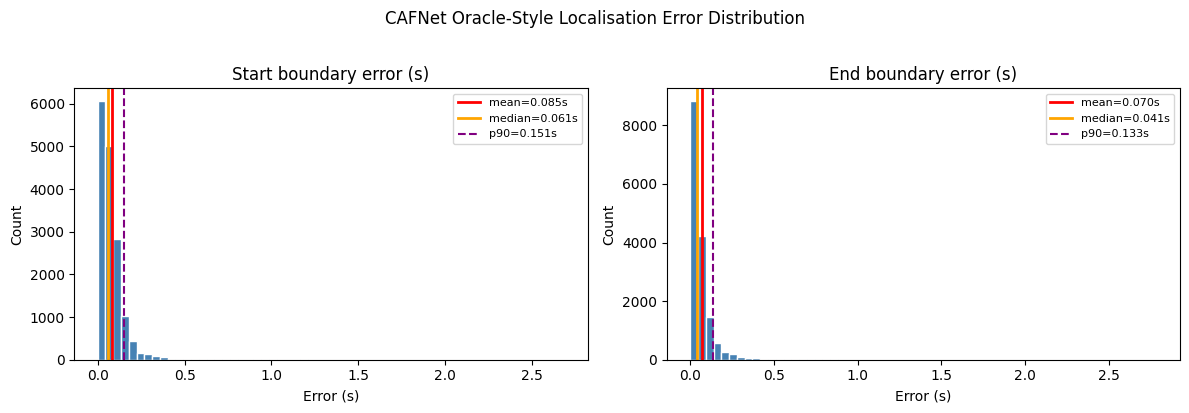


  Sample predictions vs ground truth:
   pred_start   pred_end |  true_start   true_end |  err_start  err_end |  cls
        1.11s       2.26s |       1.11s       2.13s |     0.000s    0.130s |    0
        7.82s       8.97s |       7.82s       9.00s |     0.000s    0.024s |    2
        2.10s       3.24s |       2.10s       3.20s |     0.000s    0.042s |    2
        6.12s       7.25s |       6.12s       7.36s |     0.000s    0.110s |    0
        3.71s       4.85s |       3.71s       4.89s |     0.000s    0.045s |    2
       10.04s      11.11s |      12.73s      13.90s |     2.685s    2.785s |    2

All results saved to /kaggle/working/results


In [ ]:
# ==============================================================================
# CELL 6: EVALUATION METRICS
# ==============================================================================
import json

with open(RESULTS / "oracle_style_eval_results.json") as f:
    all_results = json.load(f)

err_start = np.array([r["err_start_s"] for r in all_results])
err_end   = np.array([r["err_end_s"]   for r in all_results])
err_comb  = (err_start + err_end) / 2.0
n_files   = len(all_results)

n_correct_ht = sum(1 for r in all_results if r["pred_cls"] == 2)

print("=" * 65)
print("CAFNet Oracle-Style Evaluation — Temporal Localisation")
print(f"  N files : {n_files}")
print(f"  HT classified correctly : {n_correct_ht} ({100*n_correct_ht/n_files:.1f}%)")
print("=" * 65)

for label, err in [("Start boundary", err_start),
                   ("End boundary",   err_end),
                   ("Combined",       err_comb)]:
    print(f"\n  {label}")
    print(f"    MAE    : {err.mean():.4f}s")
    print(f"    Median : {np.median(err):.4f}s")
    print(f"    P90    : {np.percentile(err, 90):.4f}s")
    print(f"    <=0.10s: {(err <= 0.10).mean():.3f}")
    print(f"    <=0.25s: {(err <= 0.25).mean():.3f}")
    print(f"    <=0.50s: {(err <= 0.50).mean():.3f}")

# ── Comparison table ──────────────────────────────────────────────────────
oracle = {"mae": 0.075, "median": 0.052, "p90": 0.131}
ours   = {"mae": err_comb.mean(),
          "median": np.median(err_comb),
          "p90": np.percentile(err_comb, 90)}

print()
print("=" * 65)
print("COMPARISON vs Oracle-window BiLSTM (reported baseline)")
print("=" * 65)
print(f"  {'System':<38} {'MAE':>6}  {'Median':>7}  {'P90':>7}")
print("-" * 65)
print(f"  {'Oracle-window BiLSTM':<38} "
      f"{oracle['mae']:>6.3f}s {oracle['median']:>7.3f}s  {oracle['p90']:>7.3f}s")
print(f"  {'CAFNet TemporalHead':<38} "
      f"{ours['mae']:>6.3f}s {ours['median']:>7.3f}s  {ours['p90']:>7.3f}s")
print("=" * 65)

# ── Breakdown: correctly classified vs misclassified ─────────────────────
for grp, name in [
    ([r for r in all_results if r["pred_cls"] == 2], "Correctly classified HT"),
    ([r for r in all_results if r["pred_cls"] != 2], "Misclassified"),
]:
    if not grp:
        continue
    ec = (np.array([r["err_start_s"] for r in grp]) +
          np.array([r["err_end_s"]   for r in grp])) / 2
    print(f"\n  {name} ({len(grp)} files):")
    print(f"    MAE={ec.mean():.4f}s  Median={np.median(ec):.4f}s  "
          f"<=0.10s={( ec<=0.10).mean():.3f}  <=0.25s={( ec<=0.25).mean():.3f}")

# ── Error distribution plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, err, title in [
    (axes[0], err_start, "Start boundary error (s)"),
    (axes[1], err_end,   "End boundary error (s)"),
]:
    ax.hist(err, bins=60, color="steelblue", edgecolor="white")
    ax.axvline(err.mean(),             color="red",    lw=2,
               label=f"mean={err.mean():.3f}s")
    ax.axvline(np.median(err),         color="orange", lw=2,
               label=f"median={np.median(err):.3f}s")
    ax.axvline(np.percentile(err, 90), color="purple", lw=1.5, ls="--",
               label=f"p90={np.percentile(err, 90):.3f}s")
    ax.set_title(title)
    ax.set_xlabel("Error (s)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("CAFNet Oracle-Style Localisation Error Distribution", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / "oracle_eval_error_distribution.png", dpi=120)
plt.show()

# ── Sample predictions table ──────────────────────────────────────────────
print("\n  Sample predictions vs ground truth:")
print(f"  {'pred_start':>11} {'pred_end':>10} | {'true_start':>11} "
      f"{'true_end':>10} | {'err_start':>10} {'err_end':>8} | {'cls':>4}")
sorted_by_err = sorted(all_results, key=lambda r: r["err_start_s"])
for r in sorted_by_err[:5] + [sorted_by_err[-1]]:
    print(f"  {r['pred_start']:>10.2f}s {r['pred_end']:>10.2f}s | "
          f"{r['true_start']:>10.2f}s {r['true_end']:>10.2f}s | "
          f"{r['err_start_s']:>9.3f}s {r['err_end_s']:>8.3f}s | "
          f"{r['pred_cls']:>4}")

print("\nAll results saved to", RESULTS)


Demo 1/6 [Best]: sanskarit_249_hifi


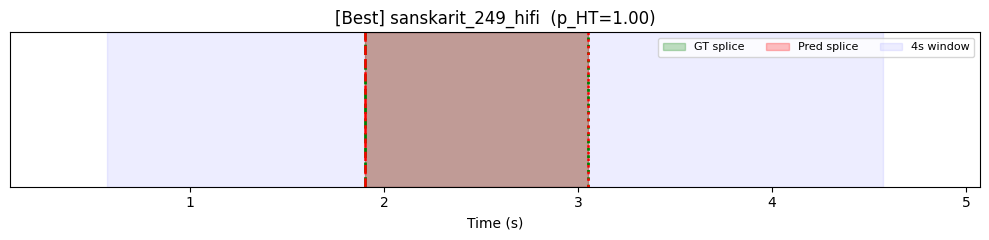

  GT    : 1.901s -- 3.054s
  Pred  : 1.902s -- 3.054s
  Error : start=0.000s  end=0.000s  combined=0.000s
  Class predicted: 2  p(HT)=0.997

Demo 2/6 [Best]: vitnamese_247_bigv


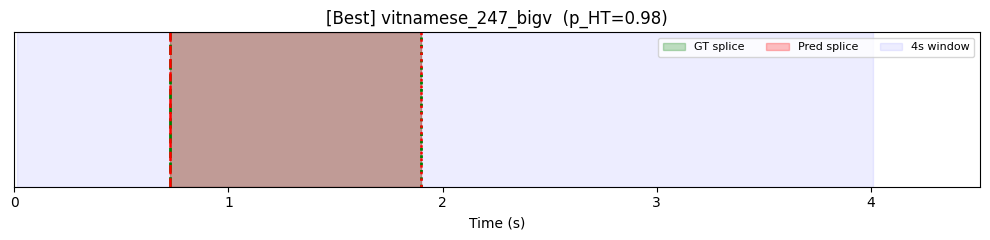

  GT    : 0.726s -- 1.899s
  Pred  : 0.726s -- 1.900s
  Error : start=0.000s  end=0.001s  combined=0.001s
  Class predicted: 2  p(HT)=0.984

Demo 3/6 [Best]: bengali_3695_hifi


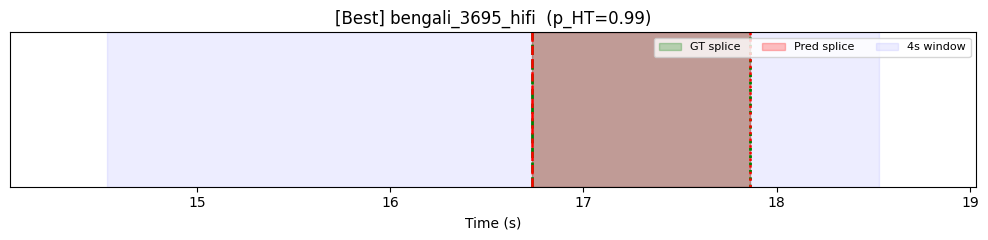

  GT    : 16.732s -- 17.861s
  Pred  : 16.731s -- 17.862s
  Error : start=0.000s  end=0.001s  combined=0.001s
  Class predicted: 2  p(HT)=0.988

Demo 4/6 [Hard case]: punjabi_3755_bigv


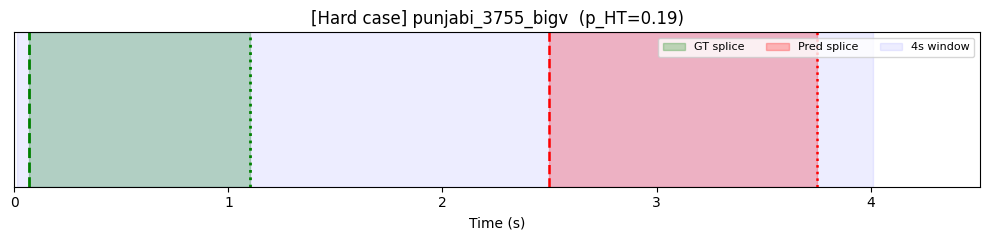

  GT    : 0.066s -- 1.103s
  Pred  : 2.497s -- 3.750s
  Error : start=2.431s  end=2.648s  combined=2.539s
  Class predicted: 1  p(HT)=0.194

Demo 5/6 [Hard case]: bengali_3819_hifi


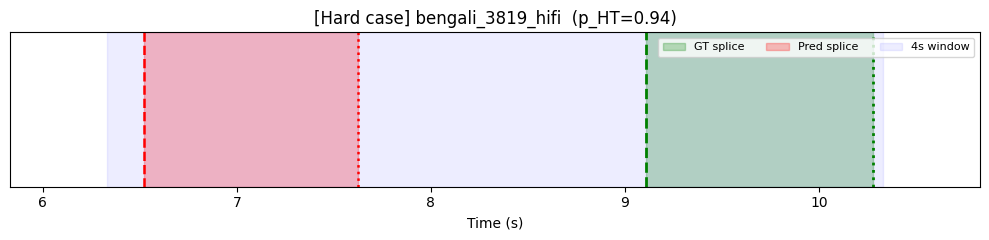

  GT    : 9.109s -- 10.278s
  Pred  : 6.523s -- 7.623s
  Error : start=2.586s  end=2.655s  combined=2.621s
  Class predicted: 2  p(HT)=0.943

Demo 6/6 [Hard case]: arabic_54_bigv


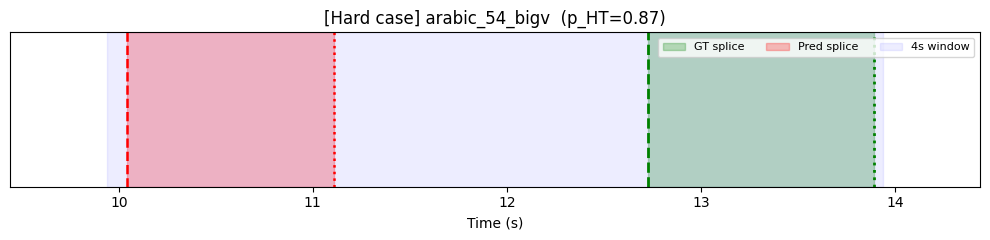

  GT    : 12.727s -- 13.895s
  Pred  : 10.042s -- 11.110s
  Error : start=2.685s  end=2.785s  combined=2.735s
  Class predicted: 2  p(HT)=0.872


In [ ]:
# ==============================================================================
# CELL 7: QUALITATIVE DEMO  (6 test files: 3 best, 3 worst)
# ==============================================================================

def plot_oracle_demo(r: dict, title: str = "", save_name: str = "demo.png"):
    """
    For oracle-style eval there is no sliding-window probability curve
    (we used a single window). Plot predicted vs GT boundaries on a
    simple timeline instead.
    """
    fig, ax = plt.subplots(figsize=(10, 2.5))

    # Ground-truth splice span
    ax.axvspan(r["true_start"], r["true_end"],
               alpha=0.25, color="green", label="GT splice")
    # Predicted splice span
    ax.axvspan(r["pred_start"], r["pred_end"],
               alpha=0.25, color="red",   label="Pred splice")

    # Boundary lines
    ax.axvline(r["true_start"],  color="green", lw=2,   ls="--")
    ax.axvline(r["true_end"],    color="green", lw=2,   ls=":")
    ax.axvline(r["pred_start"],  color="red",   lw=1.8, ls="--")
    ax.axvline(r["pred_end"],    color="red",   lw=1.8, ls=":")

    # Window extent
    w_end = r["w_start_s"] + WIN_DURATION
    ax.axvspan(r["w_start_s"], w_end,
               alpha=0.07, color="blue", label="4s window")

    ax.set_xlim(max(0, r["w_start_s"] - 0.5), w_end + 0.5)
    ax.set_xlabel("Time (s)")
    ax.set_yticks([])
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8, ncol=3)
    plt.tight_layout()
    plt.savefig(RESULTS / save_name, dpi=120)
    plt.show()

    err_s = r["err_start_s"]
    err_e = r["err_end_s"]
    print(f"  GT    : {r['true_start']:.3f}s -- {r['true_end']:.3f}s")
    print(f"  Pred  : {r['pred_start']:.3f}s -- {r['pred_end']:.3f}s")
    print(f"  Error : start={err_s:.3f}s  end={err_e:.3f}s  "
          f"combined={((err_s+err_e)/2):.3f}s")
    print(f"  Class predicted: {r['pred_cls']}  p(HT)={r['prob_ht']:.3f}")


# ── Sort by combined error, pick 3 best and 3 worst ───────────────────────
sorted_results = sorted(all_results,
                        key=lambda r: (r["err_start_s"] + r["err_end_s"]) / 2)
best3  = sorted_results[:3]
worst3 = sorted_results[-3:]

for i, r in enumerate(best3 + worst3, start=1):
    label = "Best" if i <= 3 else "Hard case"
    print(f"\n{'='*60}")
    print(f"Demo {i}/6 [{label}]: {r['stem']}")
    plot_oracle_demo(
        r,
        title=f"[{label}] {r['stem']}  (p_HT={r['prob_ht']:.2f})",
        save_name=f"demo_oracle_{i}.png",
    )